# SARID: Rainfall Intensity Estimation (Regression)
## Replicating the paper: MFCC + Transformer baseline

**Paper**: *Estimating rainfall intensity based on surveillance audio and deep-learning* (Environmental Science and Ecotechnology, 2024)

- **Task**: Regression — predict rainfall intensity (mm/h) from audio
- **Features**: MFCC (128 × 173)
- **Model**: Transformer encoder (4 layers, 4 heads, dim_feedforward=512)
- **Loss**: Smooth L1 | **Metrics**: MAE, RMSE, R²
- **Reported**: MAE 0.563, RMSE 0.88, R² 0.765

## 1. Setup and imports

In [1]:
try:
    import torch
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "numpy", "pandas", "matplotlib", "librosa", "tqdm", "scikit-learn"])
    print("Packages installed. Restart kernel and run again.")
    raise SystemExit(0)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import librosa
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Paths and config (paper settings)

In [2]:
SARID_DIR = "/home/amani/phd/rain_detection/SARID"
TRAIN_DIR = os.path.join(SARID_DIR, "split/audio_without_background_split_nocoverage_train")
TEST_DIR = os.path.join(SARID_DIR, "split/audio_without_background_split_nocoverage_test")

# Paper: MFCC 128 coeffs, 173 time frames (4s @ ~43 fps)
N_MFCC = 128
TARGET_FRAMES = 173
SR = 22050
DURATION_SEC = 4

print(f"Train exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test exists: {os.path.exists(TEST_DIR)}")
if os.path.exists(TRAIN_DIR):
    n_train = len([f for f in os.listdir(TRAIN_DIR) if f.endswith('.mp3')])
    n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith('.mp3')]) if os.path.exists(TEST_DIR) else 0
    print(f"Train samples: {n_train}, Test samples: {n_test}")

Train exists: True
Test exists: True
Train samples: 8441, Test samples: 3625


## 3. Parse filename → rainfall intensity (regression target)

In [3]:
def parse_rainfall_intensity(filename):
    if not filename.endswith('.mp3'):
        return None
    try:
        name = filename.replace('.mp3', '').strip()
        if '_segment' in name:
            name = name.split('_segment')[0]
        if '_cut[' in name:
            name = name.split('_cut[')[0]
        parts = name.split('_')
        if len(parts) < 2:
            return None
        return float(parts[1])  # rainfall intensity mm/h
    except (ValueError, IndexError):
        return None

# Quick check
train_files = [f for f in os.listdir(TRAIN_DIR) if f.endswith('.mp3')]
sample_ri = parse_rainfall_intensity(train_files[0])
print(f"Sample file: {train_files[0][:60]}...")
print(f"Parsed RI: {sample_ri} mm/h")

Sample file: 2022-10-06 16-19-00_2_12.57_97.6_1.42_2.078_hiv00052_60_road...
Parsed RI: 2.0 mm/h


## 4. MFCC extraction (128 × 173) — paper format

In [4]:
def extract_mfcc_paper(audio_path, n_mfcc=128, target_frames=173, sr=22050):
    """Extract MFCC and pad/truncate to (n_mfcc, target_frames)."""
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=DURATION_SEC)
        y = librosa.util.normalize(y)
        # MFCC: (n_mfcc, time)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
        mfcc = librosa.util.normalize(mfcc)
        # Pad or truncate time axis to target_frames
        T = mfcc.shape[1]
        if T < target_frames:
            mfcc = np.pad(mfcc, ((0, 0), (0, target_frames - T)), mode='constant', constant_values=0)
        else:
            mfcc = mfcc[:, :target_frames]
        return mfcc.astype(np.float32)
    except Exception as e:
        return None

# Test: output shape (128, 173)
sample_path = os.path.join(TRAIN_DIR, train_files[0])
mfcc_test = extract_mfcc_paper(sample_path)
print(f"MFCC shape: {mfcc_test.shape}")

MFCC shape: (128, 173)


## 5. Build file lists and labels

In [5]:
def build_meta(audio_dir):
    files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]
    meta = []
    for f in files:
        ri = parse_rainfall_intensity(f)
        if ri is not None:
            meta.append({'filename': f, 'rainfall_intensity': ri})
    return pd.DataFrame(meta)

train_meta = build_meta(TRAIN_DIR)
test_meta = build_meta(TEST_DIR)
print(f"Train: {len(train_meta)}, Test: {len(test_meta)}")
print(train_meta['rainfall_intensity'].describe())

Train: 8441, Test: 3625
count    8441.000000
mean        2.002538
std         1.806763
min         0.040000
25%         0.750000
50%         1.430000
75%         2.760000
max        14.720000
Name: rainfall_intensity, dtype: float64


## 6. Optional: use subset for quick run

In [6]:
USE_SUBSET = True
SUBSET_TRAIN = 2000
SUBSET_TEST = 800

if USE_SUBSET:
    train_meta = train_meta.sample(n=min(SUBSET_TRAIN, len(train_meta)), random_state=42)
    test_meta = test_meta.sample(n=min(SUBSET_TEST, len(test_meta)), random_state=42)
    print(f"Using subset: train {len(train_meta)}, test {len(test_meta)}")
else:
    print("Using full dataset")

Using subset: train 2000, test 800


## 7. Dataset and DataLoader

In [7]:
class SARIDRegressionDataset(Dataset):
    def __init__(self, meta_df, audio_dir, n_mfcc=128, target_frames=173):
        self.meta = meta_df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.n_mfcc = n_mfcc
        self.target_frames = target_frames

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        path = os.path.join(self.audio_dir, row['filename'])
        mfcc = extract_mfcc_paper(path, self.n_mfcc, self.target_frames)
        if mfcc is None:
            mfcc = np.zeros((self.n_mfcc, self.target_frames), dtype=np.float32)
        ri = np.float32(row['rainfall_intensity'])
        # Transformer expects (seq_len, d_model) -> (T, C)
        mfcc = mfcc.T  # (173, 128)
        return torch.from_numpy(mfcc), torch.tensor(ri, dtype=torch.float32)

train_ds = SARIDRegressionDataset(train_meta, TRAIN_DIR, N_MFCC, TARGET_FRAMES)
test_ds = SARIDRegressionDataset(test_meta, TEST_DIR, N_MFCC, TARGET_FRAMES)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Batches: train {len(train_loader)}, test {len(test_loader)}")

Batches: train 32, test 13


## 8. Model: Transformer encoder + GAP + FC (paper)

In [8]:
class TransformerRI(nn.Module):
    """Transformer encoder for rainfall intensity regression (paper setup)."""
    def __init__(self, d_model=128, nhead=4, num_layers=4, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, T, C)
        out = self.transformer(x)
        out = out.transpose(1, 2)
        out = self.gap(out).squeeze(-1)
        return self.fc(out)

model = TransformerRI(d_model=128, nhead=4, num_layers=4, dim_feedforward=512).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 1,008,001


## 9. Training: Smooth L1, Adam, warm-up + linear decay

In [9]:
def get_lr(epoch, num_epochs, warmup_epochs=5, init_lr=1e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        return init_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return max(min_lr, init_lr * (1 - progress))

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
NUM_EPOCHS = 50
warmup_epochs = 5

### 9b. Improve results (optional)
Run the cell below to use settings that often get closer to the paper (R² 0.765). Then **re-run the training loop** (the "for epoch in range(NUM_EPOCHS)" cell).
- **More epochs**: 100 (paper uses 100)
- **Larger batch**: 256 (paper uses 256)
- **Cosine LR decay** after warm-up (smoother than linear)

In [ ]:
# Improved settings (run this, then re-run the training loop below)
NUM_EPOCHS = 100
BATCH_SIZE = 256
warmup_epochs = 5
init_lr = 5e-4
min_lr = 1e-6

def get_lr(epoch, num_epochs, warmup_epochs=5, init_lr=5e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        return init_lr * (epoch + 1) / warmup_epochs
    # Cosine decay after warmup
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return min_lr + 0.5 * (init_lr - min_lr) * (1 + np.cos(np.pi * progress))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
optimizer = torch.optim.Adam(model.parameters(), lr=init_lr, weight_decay=1e-5)

history = {'train_loss': [], 'mae': [], 'rmse': [], 'r2': []}
best_r2 = -np.inf

print(f"Using NUM_EPOCHS={NUM_EPOCHS}, BATCH_SIZE={BATCH_SIZE}, cosine LR (init={init_lr}). Re-run the training loop.")

## 10. Train loop and validation (MAE, RMSE, R²)

In [10]:
def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x).squeeze(-1)
            preds.append(out.cpu().numpy())
            gts.append(y.numpy())
    preds = np.concatenate(preds)
    gts = np.concatenate(gts)
    mae = mean_absolute_error(gts, preds)
    rmse = np.sqrt(mean_squared_error(gts, preds))
    r2 = r2_score(gts, preds)
    return mae, rmse, r2

history = {'train_loss': [], 'mae': [], 'rmse': [], 'r2': []}
best_r2 = -np.inf

In [12]:
for epoch in range(NUM_EPOCHS):
    lr = get_lr(epoch, NUM_EPOCHS, warmup_epochs)
    for g in optimizer.param_groups:
        g['lr'] = lr

    model.train()
    train_loss = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)

    mae, rmse, r2 = evaluate(model, test_loader)
    history['mae'].append(mae)
    history['rmse'].append(rmse)
    history['r2'].append(r2)

    if r2 > best_r2:
        best_r2 = r2
        torch.save(model.state_dict(), 'best_sarid_regression.pth')

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}", flush=True)


Epoch 1/50 | Loss: 0.8538 | MAE: 1.1816 | RMSE: 1.8146 | R²: -0.0299


Epoch 2/50 | Loss: 0.7491 | MAE: 1.0906 | RMSE: 1.6799 | R²: 0.1173


Epoch 3/50 | Loss: 0.6666 | MAE: 0.9950 | RMSE: 1.5431 | R²: 0.2552


Epoch 4/50 | Loss: 0.5764 | MAE: 0.8362 | RMSE: 1.3968 | R²: 0.3898


Epoch 5/50 | Loss: 0.5141 | MAE: 0.7839 | RMSE: 1.3110 | R²: 0.4624


...

Epoch 46/50 | Loss: 0.2864 | MAE: 0.6451 | RMSE: 1.0009 | R²: 0.6867


Epoch 47/50 | Loss: 0.2884 | MAE: 0.6384 | RMSE: 0.9953 | R²: 0.6901


Epoch 48/50 | Loss: 0.2852 | MAE: 0.6444 | RMSE: 0.9988 | R²: 0.6880


Epoch 49/50 | Loss: 0.2801 | MAE: 0.6331 | RMSE: 0.9953 | R²: 0.6902


Epoch 50/50 | Loss: 0.2791 | MAE: 0.6359 | RMSE: 0.9944 | R²: 0.6907


## 11. Load best model and final metrics

In [13]:
model.load_state_dict(torch.load('best_sarid_regression.pth', weights_only=True))
mae, rmse, r2 = evaluate(model, test_loader)
print("="*50)
print("Final test set (paper metrics)")
print("="*50)
print(f"  MAE:  {mae:.4f} mm h⁻¹")
print(f"  RMSE: {rmse:.4f} mm h⁻¹")
print(f"  R²:   {r2:.4f}")
print("="*50)
print("Paper (MFCC-Transformer): MAE 0.563, RMSE 0.88, R² 0.765")

/tmp/ipykernel_297612/2185457271.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_sarid_regression.pth', weights_only=True))


Final test set (paper metrics)
  MAE:  0.6359 mm h⁻¹
  RMSE: 0.9944 mm h⁻¹
  R²:   0.6907
Paper (MFCC-Transformer): MAE 0.563, RMSE 0.88, R² 0.765


## 12. Plot: training loss and metrics

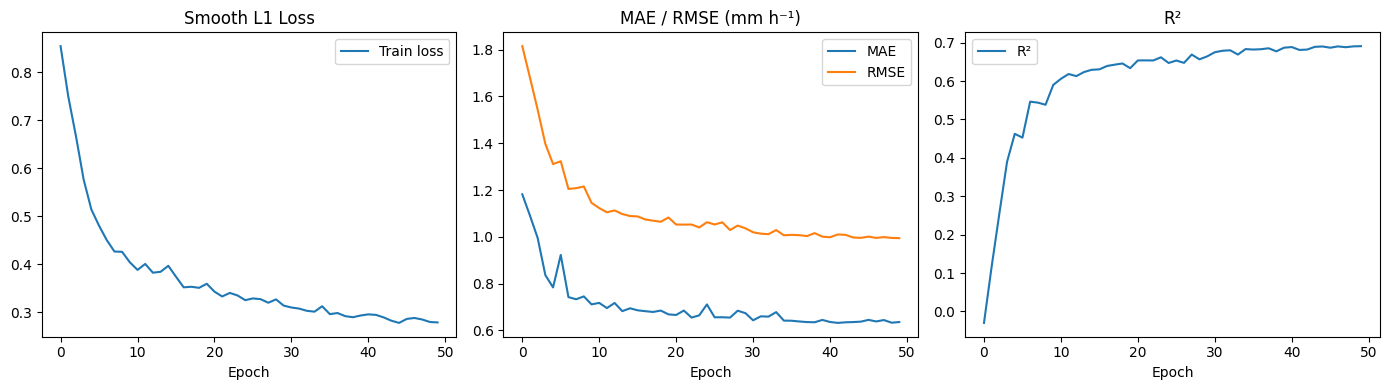

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Smooth L1 Loss')
axes[0].legend()
axes[1].plot(history['mae'], label='MAE')
axes[1].plot(history['rmse'], label='RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_title('MAE / RMSE (mm h⁻¹)')
axes[1].legend()
axes[2].plot(history['r2'], label='R²')
axes[2].set_xlabel('Epoch')
axes[2].set_title('R²')
axes[2].legend()
plt.tight_layout()
plt.show()

## 13. Scatter: predicted vs ground truth (as in paper Fig. 6)

In [ ]:
model.eval()
preds, gts = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device)).squeeze(-1).cpu().numpy()
        preds.append(out)
        gts.append(y.numpy())
preds = np.concatenate(preds)
gts = np.concatenate(gts)

plt.figure(figsize=(6, 6))
plt.scatter(gts, preds, alpha=0.4, s=10)
mx = max(gts.max(), preds.max())
plt.plot([0, mx], [0, mx], 'r--', label='Ideal')
plt.xlabel('Ground truth RI (mm h⁻¹)')
plt.ylabel('Predicted RI (mm h⁻¹)')
plt.title(f'Rainfall intensity estimation (R²={r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()